In [2]:
import pandas as pd

crop_df = pd.read_csv(r"C:\Users\Shiva Teja\Downloads\archive (8)\Crop_recommendation.csv")

crop_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print("Shape:", crop_df.shape)

print("\nData Types:")
print(crop_df.dtypes)

print("\nMissing Values:")
print(crop_df.isnull().sum())

print("\nDuplicate Rows:")
print(crop_df.duplicated().sum())

print("\nSummary Statistics:")
display(crop_df.describe())

print("\nNumber of Classes:")
print(crop_df["label"].nunique())

print("\nClass Distribution:")
print(crop_df["label"].value_counts())

Shape: (2200, 8)

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows:
0

Summary Statistics:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Number of Classes:
22

Class Distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [4]:
# Check for negative values in numerical features

numeric_features = [
    "N", "P", "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

(crop_df[numeric_features] < 0).sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
dtype: int64

In [5]:
crop_df[numeric_features].agg(["min", "max"])

,N,P,K,temperature,humidity,ph,rainfall
min,0,5,5,8.825675,14.258040,3.504752,20.211267
max,140,145,205,43.675493,99.981876,9.935091,298.560117


In [6]:
for col in numeric_features:
    print(f"\n{col}")
    print("Unique values:", crop_df[col].nunique())


N
Unique values: 137

P
Unique values: 117

K
Unique values: 73

temperature
Unique values: 2200

humidity
Unique values: 2200

ph
Unique values: 2200

rainfall
Unique values: 2200


In [7]:
print(crop_df["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [8]:
print("Number of crop classes:", crop_df["label"].nunique())

Number of crop classes: 22


In [9]:
crop_df["label"].str.strip().value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [10]:
crop_df["label"] = crop_df["label"].str.strip()

In [11]:
crop_df["label"].nunique()

22

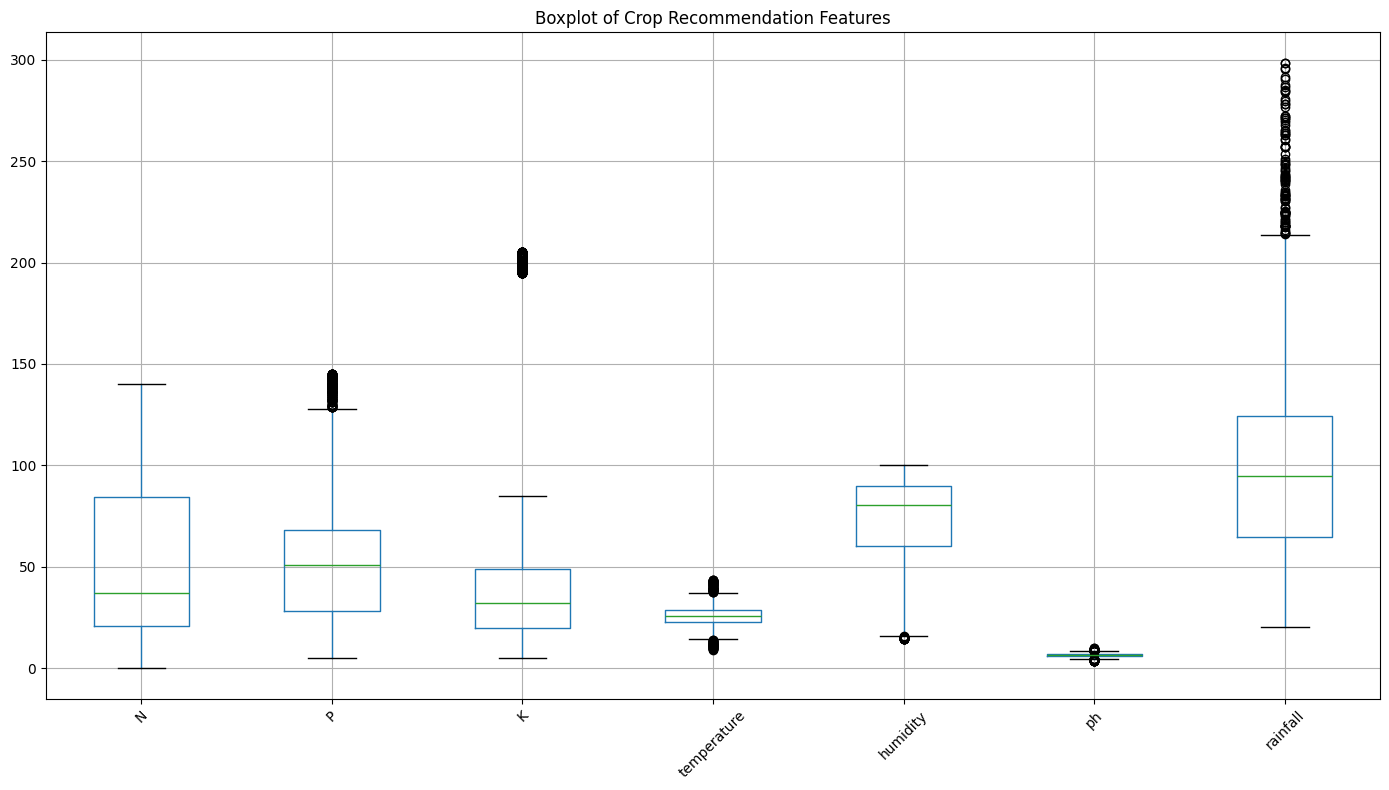

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

crop_df[numeric_features].boxplot()

plt.title("Boxplot of Crop Recommendation Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
for col in numeric_features:
    Q1 = crop_df[col].quantile(0.25)
    Q3 = crop_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = crop_df[
        (crop_df[col] < lower) |
        (crop_df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} potential outliers")

N: 0 potential outliers
P: 138 potential outliers
K: 200 potential outliers
temperature: 86 potential outliers
humidity: 30 potential outliers
ph: 57 potential outliers
rainfall: 100 potential outliers


In [14]:
# Outlier Analysis using IQR

features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

outlier_summary = {}

for feature in features:
    
    Q1 = crop_df[feature].quantile(0.25)
    Q3 = crop_df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = crop_df[
        (crop_df[feature] < lower_bound) |
        (crop_df[feature] > upper_bound)
    ]
    
    outlier_summary[feature] = len(outliers)

print("Potential Outliers:")
for feature, count in outlier_summary.items():
    print(f"{feature}: {count}")

Potential Outliers:
N: 0
P: 138
K: 200
temperature: 86
humidity: 30
ph: 57
rainfall: 100


In [15]:
# Separate features and target

X = crop_df.drop("label", axis=1)
y = crop_df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Feature shape: (2200, 7)
Target shape: (2200,)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [17]:
# ==============================
# Feature Scaling
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (1760, 7)
Scaled testing shape: (440, 7)


In [18]:
# ==============================
# Target Encoding
# ==============================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Encoded classes:")
print(label_encoder.classes_)

print("\nNumber of classes:", len(label_encoder.classes_))

Encoded classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']

Number of classes: 22


In [19]:
print("\nFinal Dataset Information")
print("-------------------------")
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train_encoded.shape)
print("y_test :", y_test_encoded.shape)


Final Dataset Information
-------------------------
X_train: (1760, 7)
X_test : (440, 7)
y_train: (1760,)
y_test : (440,)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original labels:")
print(y.unique())

print("\nEncoded labels:")
print(y_encoded[:20])

print("\nClass mapping:")
for class_name, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{class_name} -> {encoded_value}")

Original labels:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Encoded labels:
[20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20]

Class mapping:
apple -> 0
banana -> 1
blackgram -> 2
chickpea -> 3
coconut -> 4
coffee -> 5
cotton -> 6
grapes -> 7
jute -> 8
kidneybeans -> 9
lentil -> 10
maize -> 11
mango -> 12
mothbeans -> 13
mungbean -> 14
muskmelon -> 15
orange -> 16
papaya -> 17
pigeonpeas -> 18
pomegranate -> 19
rice -> 20
watermelon -> 21


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Encode target after splitting
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train_encoded.shape)
print("y_test :", y_test_encoded.shape)

print("\nNumber of classes:", len(label_encoder.classes_))
print("\nClass mapping:")

for class_name, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"{class_name} -> {encoded_value}")

X_train: (1760, 7)
X_test : (440, 7)
y_train: (1760,)
y_test : (440,)

Number of classes: 22

Class mapping:
apple -> 0
banana -> 1
blackgram -> 2
chickpea -> 3
coconut -> 4
coffee -> 5
cotton -> 6
grapes -> 7
jute -> 8
kidneybeans -> 9
lentil -> 10
maize -> 11
mango -> 12
mothbeans -> 13
mungbean -> 14
muskmelon -> 15
orange -> 16
papaya -> 17
pigeonpeas -> 18
pomegranate -> 19
rice -> 20
watermelon -> 21


In [22]:
# ==========================================
# BASELINE MODEL TRAINING
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

In [23]:
# ==========================================
# BASELINE MODEL TRAINING
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

In [24]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

In [25]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingClassifier(
    random_state=42
)

In [26]:
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

In [27]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    return accuracy, precision, recall, f1

In [28]:
results = []

for name, model in models.items():

    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_train,
        X_test,
        y_train_encoded,
        y_test_encoded
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.995455,0.995671,0.995455,0.995452
5,Gradient Boosting,0.988636,0.989742,0.988636,0.988723
2,SVM,0.984091,0.985610,0.984091,0.984038
3,Decision Tree,0.979545,0.980598,0.979545,0.979423
1,KNN,0.979545,0.980356,0.979545,0.979283
0,Logistic Regression,0.972727,0.974022,0.972727,0.972464


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train_encoded,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision_weighted"].mean(),
        "CV Recall Mean": scores["test_recall_weighted"].mean(),
        "CV F1 Mean": scores["test_f1_weighted"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="CV F1 Mean",
    ascending=False
)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean
4,Random Forest,0.993750,0.006067,0.994557,0.993750,0.993703
5,Gradient Boosting,0.986932,0.003409,0.988090,0.986932,0.986861
3,Decision Tree,0.985227,0.006818,0.986517,0.985227,0.985209
2,SVM,0.978977,0.010259,0.982154,0.978977,0.978803
0,Logistic Regression,0.968182,0.006577,0.971012,0.968182,0.967824
1,KNN,0.965341,0.012106,0.969727,0.965341,0.965011


In [31]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [32]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="f1_weighted",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train_encoded
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [33]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation F1:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best Cross-Validation F1:
0.9954333087080703


In [34]:
# ==========================================
# FINAL TEST EVALUATION
# ==========================================

best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)

final_accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

final_precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

final_recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

final_f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print("Final Random Forest Performance")
print("--------------------------------")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

Final Random Forest Performance
--------------------------------
Accuracy  : 0.9932
Precision : 0.9935
Recall    : 0.9932
F1 Score  : 0.9932


In [35]:
from sklearn.metrics import classification_report

In [36]:
print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
   

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Final Random Forest Performance")
print("--------------------------------")

print(f"Accuracy  : {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"Precision : {precision_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_test_encoded, y_pred, average='weighted'):.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Final Random Forest Performance
--------------------------------
Accuracy  : 0.9932
Precision : 0.9935
Recall    : 0.9932
F1 Score  : 0.9932

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00 

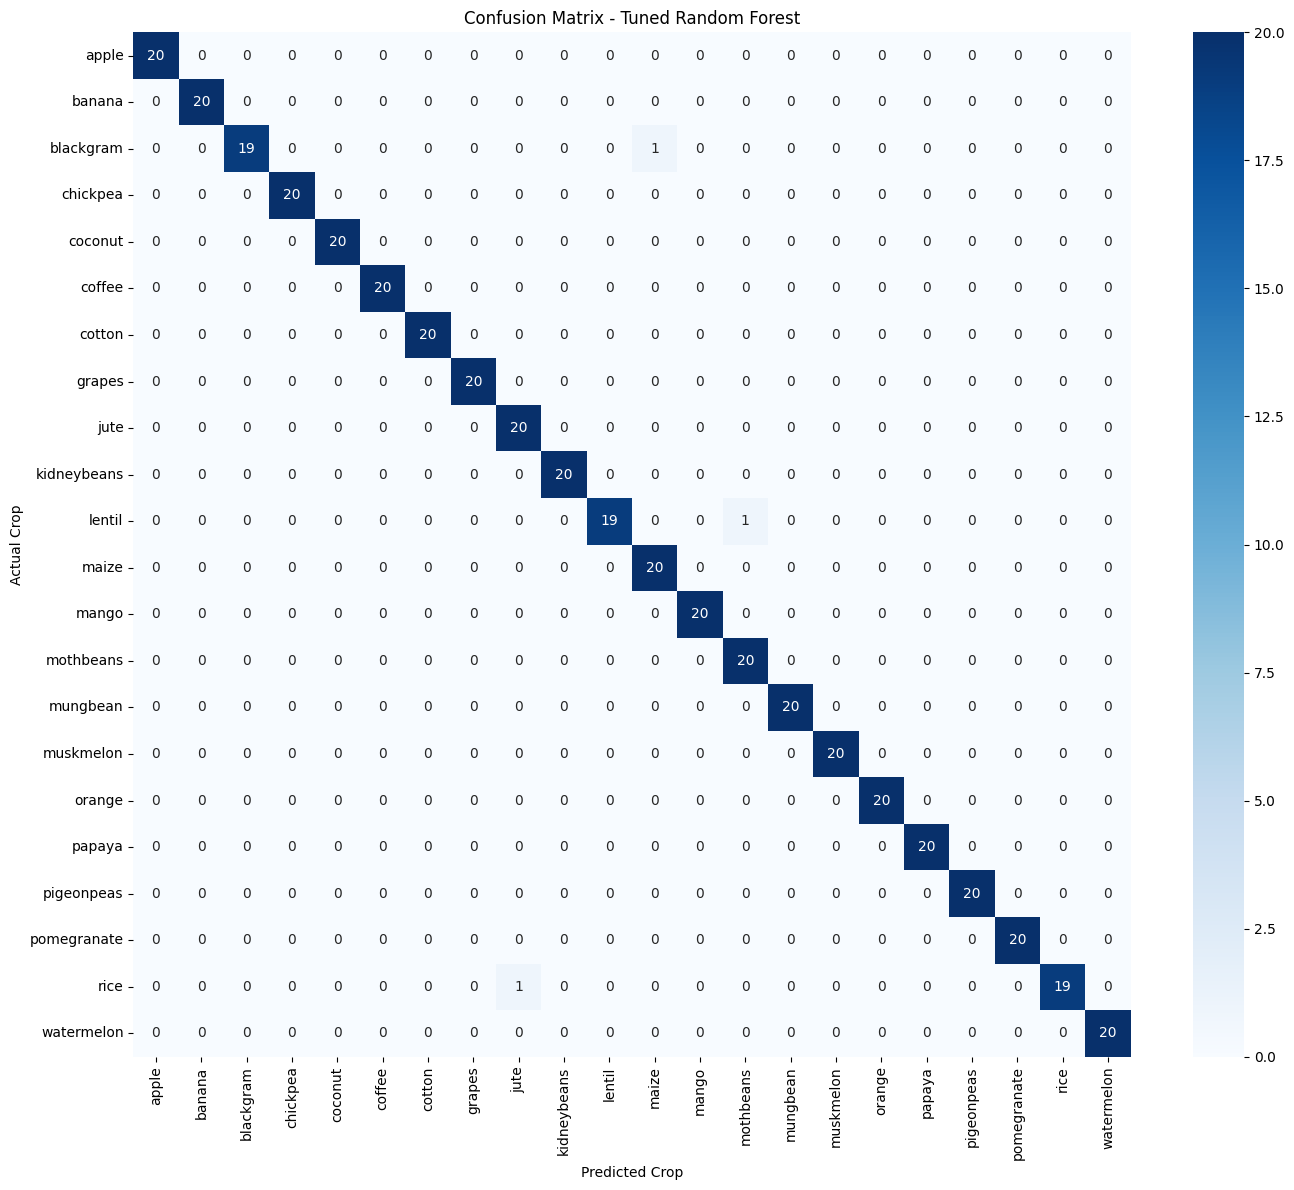

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
error_indices = y_test_encoded != y_pred

errors = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(
        y_test_encoded[error_indices]
    ),
    "Predicted": label_encoder.inverse_transform(
        y_pred[error_indices]
    )
})

print("Total incorrect predictions:", len(errors))

errors

Total incorrect predictions: 3


,Actual,Predicted
0,blackgram,maize
1,lentil,mothbeans
2,rice,jute


In [40]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
       Feature  Importance
6     rainfall    0.226874
4     humidity    0.214284
2            K    0.176271
1            P    0.156165
0            N    0.102895
3  temperature    0.072887
5           ph    0.050623


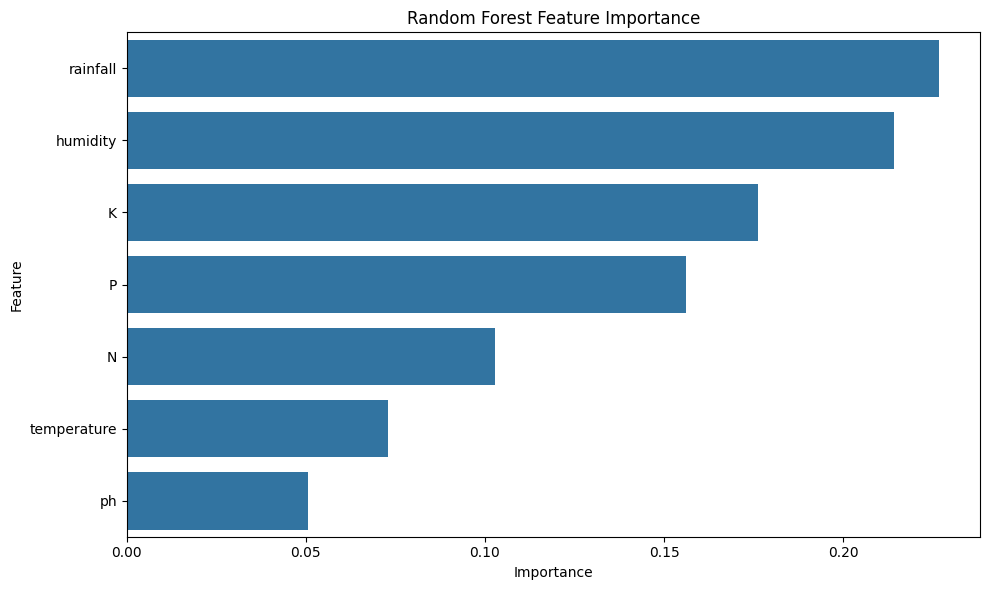

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [42]:
best_rf

RandomForestClassifier(min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [43]:
import joblib

# Save the trained Random Forest model
joblib.dump(best_rf, "crop_recommendation_model.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model and Label Encoder saved successfully!")

Model and Label Encoder saved successfully!


In [44]:
import joblib

# Load the saved model
loaded_model = joblib.load("crop_recommendation_model.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

# Test prediction using saved model
sample_prediction = loaded_model.predict(X_test.iloc[:5])

# Convert encoded predictions back to crop names
predicted_crops = loaded_encoder.inverse_transform(sample_prediction)

print("Predicted crops:")
print(predicted_crops)

Predicted crops:
['orange' 'banana' 'cotton' 'maize' 'orange']


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

# Predictions from the trained encoded-label model
y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)

precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Crop Recommendation Model Evaluation")
print("--------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print("---------------------")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# Use encoded labels consistently with model predictions
f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Crop Recommendation Model Evaluation")
print("--------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print("---------------------")
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Crop Recommendation Model Evaluation
--------------------------------------
Accuracy  : 0.9932
Precision : 0.9935
Recall    : 0.9932
F1 Score  : 0.9932

Classification Report
---------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98   